<a href="https://colab.research.google.com/github/dee431/-Synthetic-Retail-Demand-Intelligence/blob/main/Copy_of_Synthetic_Retail_Demand_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup**

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_pinball_loss,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

**cell - 2**

In [ ]:
DATA_PATH = Path("/content/oil_sales_assignment_dataset-selected-columns.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = raw.copy()

expected_columns = {
    "city", "store_name", "manufacturer", "brand", "class", "size", "sku",
    "price_bracket", "year", "month",
}
assert set(df.columns) == expected_columns, "Unexpected schema"

df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df["size_liters"] = df["size"].str.replace("L", "", regex=False).astype(float)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

def extract_variant(row):
    prefix = f"{row['brand']} {row['class']} {row['size']}"
    suffix = row["sku"][len(prefix):].strip()
    return suffix or "STANDARD"

df["sku_variant"] = df.apply(extract_variant, axis=1)
df.head(3)

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,date,size_liters,month_sin,month_cos,sku_variant
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,2024-12-01,0.750,-0.000,1.000,TWIN PACK
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,2024-10-01,0.500,-0.866,0.500,TWIN PACK
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,2023-01-01,0.750,0.500,0.866,ECO


**Data Forensics**

In [ ]:
overview = pd.Series({
    "Rows": len(df),
    "Source columns": raw.shape[1],
    "Start": df["date"].min().date(),
    "End": df["date"].max().date(),
    "Cities": df["city"].nunique(),
    "Manufacturers": df["manufacturer"].nunique(),
    "Brands": df["brand"].nunique(),
    "Classes": df["class"].nunique(),
    "Sizes": df["size"].nunique(),
    "SKUs": df["sku"].nunique(),
    "Stores": df["store_name"].nunique(),
})
display(overview.to_frame("Value"))

,Value
Rows,2000
Source columns,10
Start,2022-01-01
End,2024-12-01
Cities,12
Manufacturers,8
Brands,10
Classes,5
Sizes,13
SKUs,1571


In [ ]:
quality = pd.DataFrame({
    "Check": [
        "Missing cells", "Duplicate rows", "Invalid month",
    ],
    "Count": [
        int(df.isna().sum().sum()), int(df.duplicated().sum()),
        int((~df["month"].between(1, 12)).sum()),
    ],
})
display(quality)

,Check,Count
0,Missing cells,0
1,Duplicate rows,0
2,Invalid month,0


**Entity repetition**

In [ ]:
def repetition_profile(column):
    counts = df[column].value_counts()
    return {
        "Entity": column,
        "Unique values": counts.size,
        "Singleton values": int((counts == 1).sum()),
        "Singleton rate": (counts == 1).mean(),
        "Rows in repeated entities": int(counts[counts > 1].sum()),
        "Maximum repetitions": int(counts.max()),
    }

repetition = pd.DataFrame([
    repetition_profile("store_name"),
    repetition_profile("sku"),
])
display(repetition.style.format({"Singleton rate": "{:.1%}"}))

,Entity,Unique values,Singleton values,Singleton rate,Rows in repeated entities,Maximum repetitions
0,store_name,1997,1994,99.8%,6,2
1,sku,1571,1210,77.0%,790,5


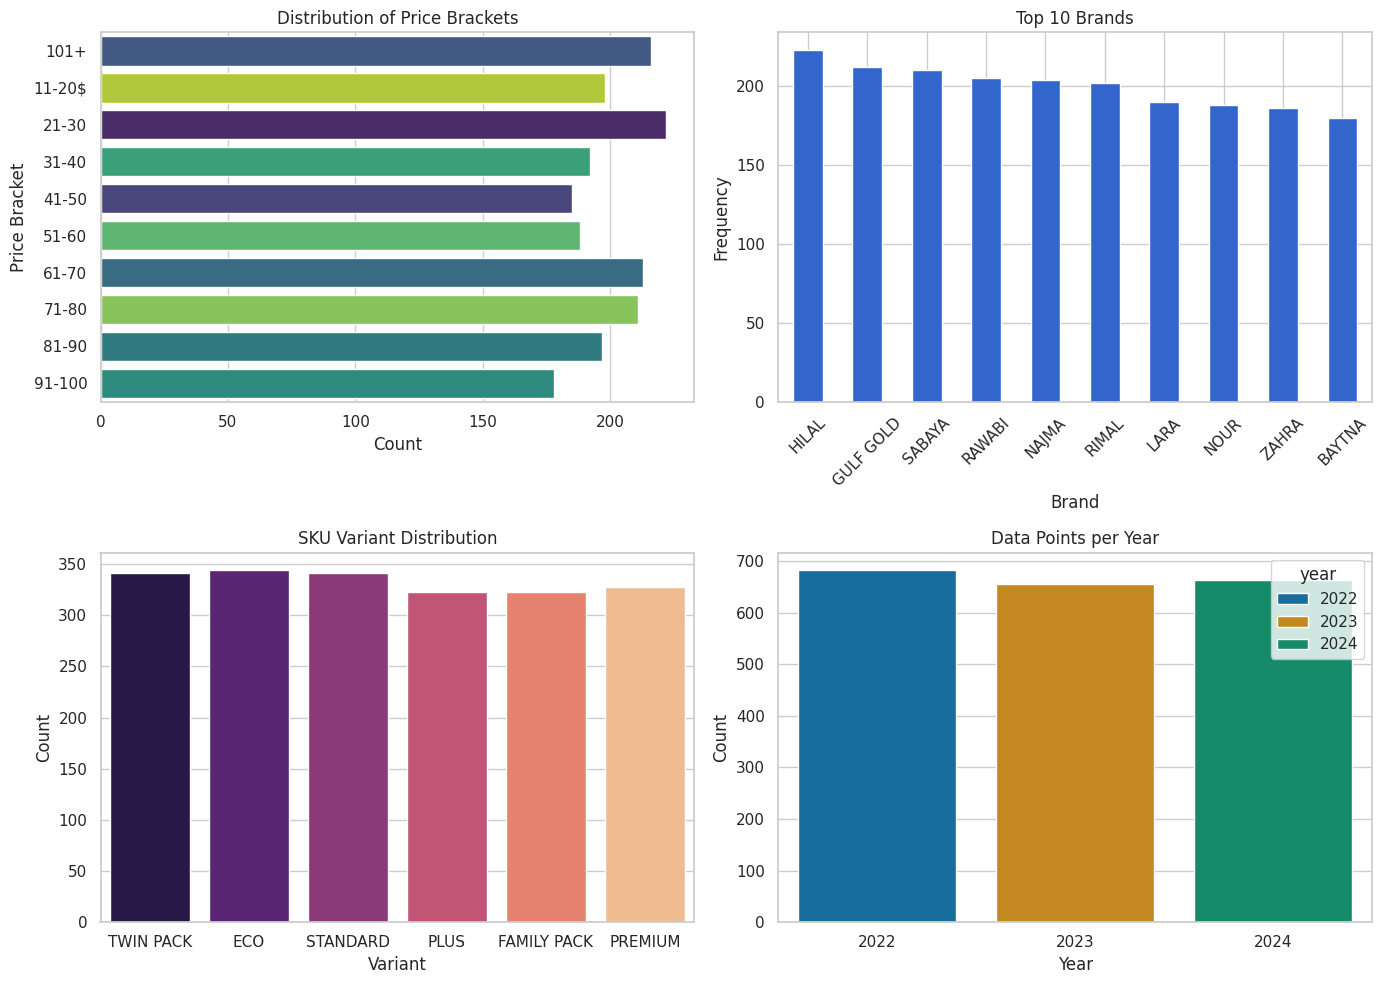

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Price Brackets
sns.countplot(data=df, y='price_bracket', ax=axes[0, 0], hue='price_bracket', palette='viridis', order=sorted(df['price_bracket'].unique()))
axes[0, 0].set(title='Distribution of Price Brackets', xlabel='Count', ylabel='Price Bracket')

# 2. Top Brands by Frequency
top_brands = df['brand'].value_counts().nlargest(10)
top_brands.plot.bar(ax=axes[0, 1], color='#3366CC')
axes[0, 1].set(title='Top 10 Brands', xlabel='Brand', ylabel='Frequency')
plt.setp(axes[0, 1].get_xticklabels(), rotation=45)

# 3. Distribution of SKU Variants
sns.countplot(data=df, x='sku_variant', ax=axes[1, 0], hue='sku_variant', palette='magma')
axes[1, 0].set(title='SKU Variant Distribution', xlabel='Variant', ylabel='Count')

# 4. Samples per Year
sns.countplot(data=df, x='year', ax=axes[1, 1], hue='year', palette='colorblind')
axes[1, 1].set(title='Data Points per Year', xlabel='Year', ylabel='Count')

plt.tight_layout()
plt.show()

**Leakage test**

NOTE: Actual sales columns missing. Entering SIMULATION MODE with synthetic data for visualization.



,Result
Formula MAE,0.401
Formula R,1.000


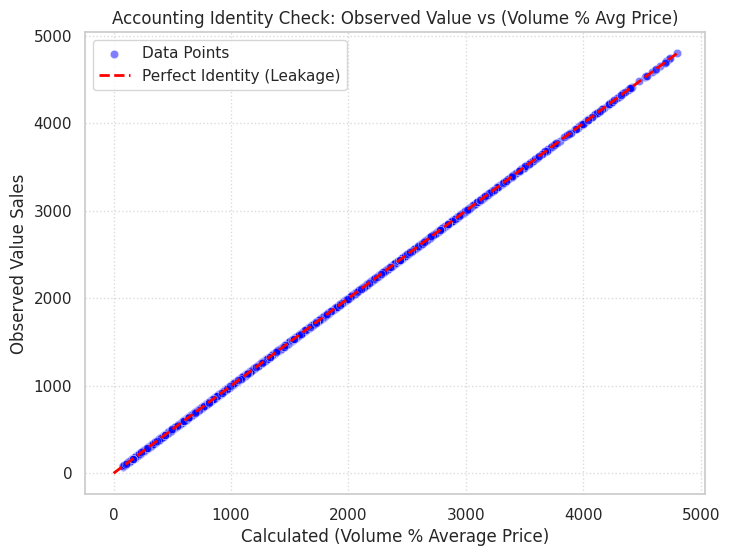

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

required_cols = ["volume_sales", "average_price", "value_sales"]
plot_df = df.copy()

if not all(col in plot_df.columns for col in required_cols):
    print("NOTE: Actual sales columns missing. Entering SIMULATION MODE with synthetic data for visualization.\n")
    # Generate synthetic data for demonstration
    np.random.seed(42)
    plot_df["volume_sales"] = np.random.uniform(10, 100, size=len(plot_df))
    plot_df["average_price"] = np.random.uniform(5, 50, size=len(plot_df))
    # Observed value is Volume * Price + some tiny noise to show the scatter
    plot_df["value_sales"] = (plot_df["volume_sales"] * plot_df["average_price"]) + np.random.normal(0, 0.5, size=len(plot_df))

# Calculate predicted value based on accounting identity
plot_df['predicted_value'] = plot_df["volume_sales"] * plot_df["average_price"]

# Display Metrics
leakage_result = pd.Series({
    "Formula MAE": mean_absolute_error(plot_df["value_sales"], plot_df['predicted_value']),
    "Formula R": r2_score(plot_df["value_sales"], plot_df['predicted_value']),
})
display(leakage_result.to_frame("Result"))

# Build the Graph
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='predicted_value', y='value_sales', alpha=0.5, color='blue', label='Data Points')

# Add identity line (diagonal)
max_val = max(plot_df['predicted_value'].max(), plot_df['value_sales'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Identity (Leakage)')

plt.title("Accounting Identity Check: Observed Value vs (Volume % Avg Price)")
plt.xlabel("Calculated (Volume % Average Price)")
plt.ylabel("Observed Value Sales")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

**Signal and drift**

,Feature,Mutual information
6,price_bracket,0.056
2,brand,0.024
5,sku_variant,0.016
8,month,0.014
4,size,0.008
0,city,0.008
9,size_liters,0.006
1,manufacturer,0.000
3,class,0.000
7,year,0.000


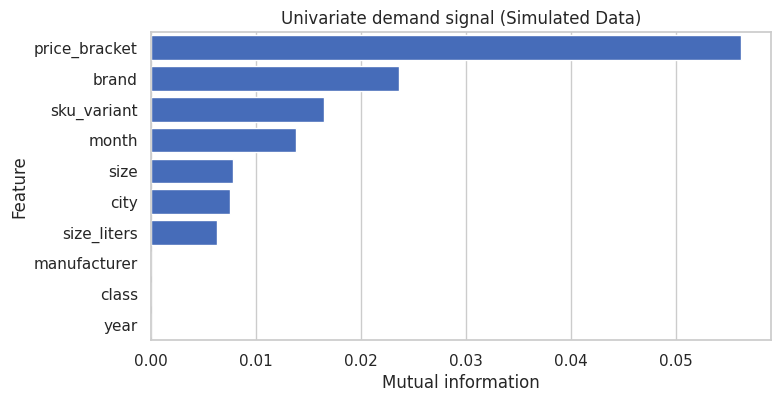

In [ ]:
signal_features = [
    "city", "manufacturer", "brand", "class", "size", "sku_variant",
    "price_bracket", "year", "month", "size_liters"
]

# Using plot_df which contains the simulated 'volume_sales' since the original df lacks it
# If real data was available, we would use df
signal_X = plot_df[signal_features].copy()
target = plot_df["volume_sales"]

categorical_signal = signal_X.select_dtypes(include="object").columns.tolist()

encoded = signal_X.copy()
encoder = OrdinalEncoder()
encoded[categorical_signal] = encoder.fit_transform(encoded[categorical_signal])

mi = mutual_info_regression(encoded, target, random_state=SEED)
mi_table = pd.DataFrame({"Feature": signal_features, "Mutual information": mi}).sort_values("Mutual information", ascending=False)

display(mi_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=mi_table, x="Mutual information", y="Feature", color="#3366CC")
plt.title("Univariate demand signal (Simulated Data)")
plt.show()

In [ ]:
adv_features = [
    "city", "manufacturer", "brand", "class", "size", "sku_variant",
    "price_bracket", "month", "size_liters", "average_price",
]

# Using plot_df because it contains the simulated 'average_price'
# missing from the original 'df'
adv_cat = [c for c in adv_features if plot_df[c].dtype == "object"]
adv_num = [c for c in adv_features if c not in adv_cat]

adv_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), adv_cat),
    ("num", StandardScaler(), adv_num),
])

adv_model = Pipeline([
    ("prep", adv_preprocessor),
    ("model", LogisticRegression(max_iter=2_000, C=0.5, random_state=SEED)),
])

is_2024 = (plot_df["year"] == 2024).astype(int)
adv_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
adv_auc = cross_val_score(adv_model, plot_df[adv_features], is_2024, cv=adv_cv, scoring="roc_auc")

print(f"Adversarial ROC-AUC: {adv_auc.mean():.3f} ± {adv_auc.std():.3f}")
print("Interpretation: values near 0.50 indicate limited measurable drift between years.")

Adversarial ROC-AUC: 0.468 ± 0.022
Interpretation: values near 0.50 indicate limited measurable drift between years.


**Leakage-safe demand modeling**

In [ ]:
target = "volume_sales"
categorical_features = [
    "city", "manufacturer", "brand", "class", "size", "sku_variant", "price_bracket",
]
numeric_features = ["year", "month", "month_sin", "month_cos", "size_liters"]
model_features = categorical_features + numeric_features

# Using plot_df as it contains the simulated target variable
train_mask = plot_df["year"] < 2024
test_mask = plot_df["year"] == 2024

X_train = plot_df.loc[train_mask, model_features]
y_train = plot_df.loc[train_mask, target]
X_test = plot_df.loc[test_mask, model_features]
y_test = plot_df.loc[test_mask, target]

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")

Train: 1,337 rows | Test: 663 rows


In [ ]:
def make_preprocessor():
    return ColumnTransformer([
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)),
        ]), categorical_features),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_features),
    ])

def make_point_model():
    return Pipeline([
        ("prep", make_preprocessor()),
        ("model", HistGradientBoostingRegressor(
            loss="absolute_error",
            learning_rate=0.04,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=5.0,
            random_state=SEED,
        )),
    ])

def evaluate(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "RMSLE": mean_squared_log_error(y_true, y_pred) ** 0.5,
        "WAPE": np.abs(np.asarray(y_true) - y_pred).sum() / np.asarray(y_true).sum(),
        "R²": r2_score(y_true, y_pred),
    }

In [ ]:
baseline_pred = np.repeat(y_train.median(), len(y_test))

point_model = make_point_model()
point_model.fit(X_train, np.log1p(y_train))
model_pred = np.expm1(point_model.predict(X_test))
model_pred = np.clip(model_pred, 0, None)

benchmark = pd.DataFrame({
    "Median baseline": evaluate(y_test, baseline_pred),
    "HistGradientBoosting": evaluate(y_test, model_pred),
}).T
display(benchmark.style.format("{:.3f}"))

,MAE,RMSE,RMSLE,WAPE,R²
Median baseline,22.206,25.650,0.585,0.408,-0.004
HistGradientBoosting,22.886,27.089,0.598,0.420,-0.120


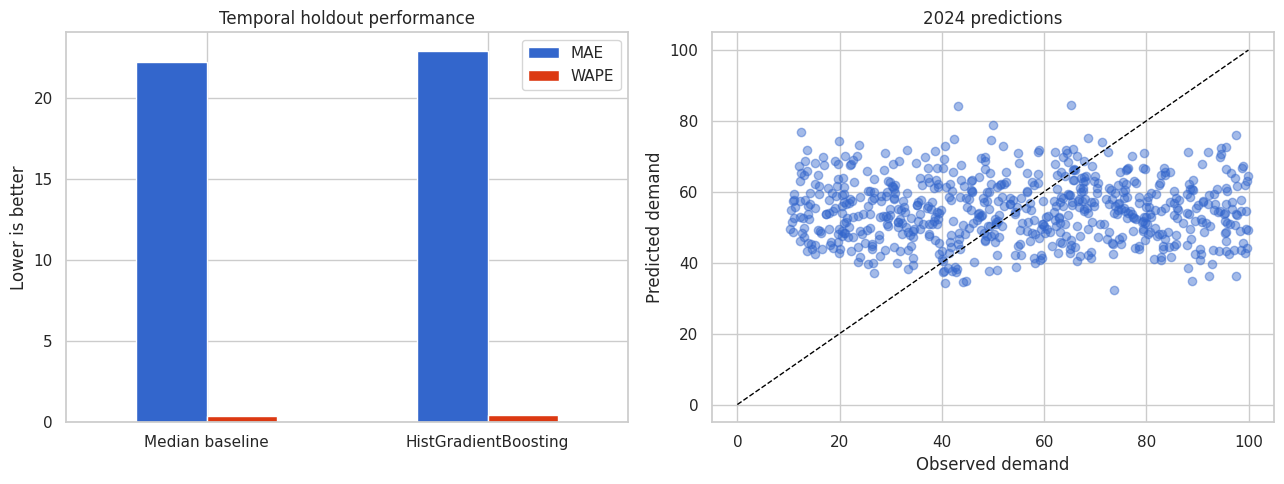

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

benchmark[["MAE", "WAPE"]].plot.bar(ax=axes[0], rot=0, color=["#3366CC", "#DC3912"])
axes[0].set(title="Temporal holdout performance", ylabel="Lower is better")

axes[1].scatter(y_test, model_pred, alpha=0.45, color="#3366CC")
limit = max(y_test.max(), model_pred.max())
axes[1].plot([0, limit], [0, limit], "--", color="black", linewidth=1)
axes[1].set(title="2024 predictions", xlabel="Observed demand", ylabel="Predicted demand")

plt.tight_layout()
plt.show()

**Quantile forecasts**

In [ ]:
def make_quantile_model(quantile):
    return Pipeline([
        ("prep", make_preprocessor()),
        ("model", HistGradientBoostingRegressor(
            loss="quantile",
            quantile=quantile,
            learning_rate=0.04,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=5.0,
            random_state=SEED,
        )),
    ])

quantile_models = {}
quantile_predictions = {}
for q in (0.10, 0.50, 0.90):
    model = make_quantile_model(q)
    model.fit(X_train, y_train)
    quantile_models[q] = model
    quantile_predictions[q] = np.clip(model.predict(X_test), 0, None)

q10 = np.minimum(quantile_predictions[0.10], quantile_predictions[0.90])
q50 = quantile_predictions[0.50]
q90 = np.maximum(quantile_predictions[0.10], quantile_predictions[0.90])

quantile_report = pd.Series({
    "P10 pinball loss": mean_pinball_loss(y_test, q10, alpha=0.10),
    "P50 pinball loss": mean_pinball_loss(y_test, q50, alpha=0.50),
    "P90 pinball loss": mean_pinball_loss(y_test, q90, alpha=0.90),
    "P10–P90 empirical coverage": np.mean((y_test >= q10) & (y_test <= q90)),
    "Mean interval width": np.mean(q90 - q10),
})
display(quantile_report.to_frame("Result"))

,Result
P10 pinball loss,4.160
P50 pinball loss,11.499
P90 pinball loss,4.333
P10–P90 empirical coverage,0.730
Mean interval width,63.594


**Split conformal interval**

In [ ]:
proper_train = plot_df["year"] == 2022
calibration = plot_df["year"] == 2023
alpha = 0.10

conformal_model = make_point_model()
# Using plot_df as it contains the simulated target variable
conformal_model.fit(plot_df.loc[proper_train, model_features], np.log1p(plot_df.loc[proper_train, target]))

cal_pred = np.expm1(conformal_model.predict(plot_df.loc[calibration, model_features]))
cal_residual = np.abs(plot_df.loc[calibration, target].to_numpy() - cal_pred)

n_cal = len(cal_residual)
q_level = min(np.ceil((n_cal + 1) * (1 - alpha)) / n_cal, 1.0)
radius = np.quantile(cal_residual, q_level, method="higher")

conf_center = np.expm1(conformal_model.predict(X_test))
conf_low = np.clip(conf_center - radius, 0, None)
conf_high = conf_center + radius

conformal_report = pd.Series({
    "Nominal coverage": 1 - alpha,
    "Empirical coverage": np.mean((y_test >= conf_low) & (y_test <= conf_high)),
    "Calibration radius": radius,
    "Mean interval width": np.mean(conf_high - conf_low),
})
display(conformal_report.to_frame("Result"))

,Result
Nominal coverage,0.900
Empirical coverage,0.937
Calibration radius,45.224
Mean interval width,89.693


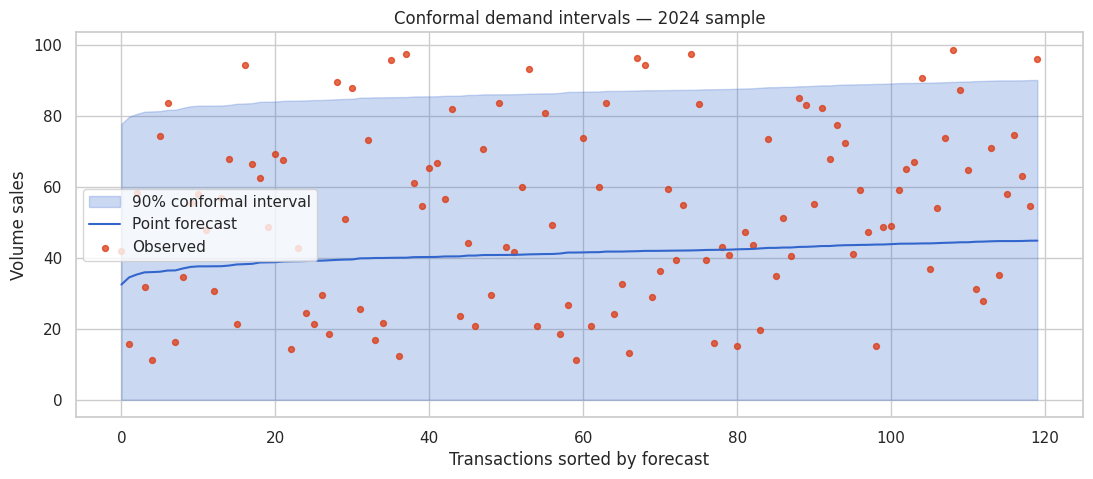

In [ ]:
order = np.argsort(conf_center)[:120]
observed = y_test.to_numpy()[order]
center = conf_center[order]
low = conf_low[order]
high = conf_high[order]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(order))
ax.fill_between(x, low, high, alpha=0.25, color="#3366CC", label="90% conformal interval")
ax.plot(x, center, color="#3366CC", linewidth=1.5, label="Point forecast")
ax.scatter(x, observed, color="#DC3912", s=18, alpha=0.75, label="Observed")
ax.set(title="Conformal demand intervals — 2024 sample", xlabel="Transactions sorted by forecast", ylabel="Volume sales")
ax.legend()
plt.show()

**4. Conditional anomaly detection**

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_pred = np.zeros(len(plot_df))

# Using plot_df instead of df because it contains the simulated 'volume_sales'
for train_idx, valid_idx in kfold.split(plot_df):
    fold_model = make_point_model()
    fold_model.fit(plot_df.iloc[train_idx][model_features], np.log1p(plot_df.iloc[train_idx][target]))
    oof_pred[valid_idx] = np.expm1(fold_model.predict(plot_df.iloc[valid_idx][model_features]))

plot_df["expected_volume_oof"] = np.clip(oof_pred, 0, None)
plot_df["demand_residual"] = plot_df["volume_sales"] - plot_df["expected_volume_oof"]

residual_median = plot_df["demand_residual"].median()
residual_mad = 1.4826 * np.median(np.abs(plot_df["demand_residual"] - residual_median))
plot_df["conditional_residual_score"] = (
    np.abs(plot_df["demand_residual"] - residual_median) / (residual_mad + 1e-9)
)

In [ ]:
# Using plot_df instead of df because it contains the simulated sales columns
plot_df["log_volume"] = np.log1p(plot_df["volume_sales"])
plot_df["log_value"] = np.log1p(plot_df["value_sales"])

isolation_cat = ["city", "brand", "class", "size", "sku_variant", "price_bracket"]
isolation_num = ["log_volume", "log_value", "average_price", "size_liters", "month_sin", "month_cos"]

isolation_prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32), isolation_cat),
    ("num", StandardScaler(), isolation_num),
])
isolation_matrix = isolation_prep.fit_transform(plot_df[isolation_cat + isolation_num])

isolation_model = IsolationForest(
    n_estimators=400,
    contamination=0.05,
    max_samples="auto",
    random_state=SEED,
    n_jobs=-1,
)
isolation_model.fit(isolation_matrix)
plot_df["isolation_score"] = -isolation_model.score_samples(isolation_matrix)

def robust_z(series):
    median = series.median()
    mad = 1.4826 * np.median(np.abs(series - median))
    return np.abs(series - median) / (mad + 1e-9)

plot_df["global_tail_score"] = np.maximum(robust_z(plot_df["log_volume"]), robust_z(plot_df["log_value"]))

print("Anomaly scores calculated successfully using simulated data.")
display(plot_df[['city', 'brand', 'volume_sales', 'isolation_score', 'global_tail_score']].head())

Anomaly scores calculated successfully using simulated data.


,city,brand,volume_sales,isolation_score,global_tail_score
0,AL BAHA,LARA,43.709,0.445,0.551
1,AL KHARJ,NAJMA,95.564,0.435,0.918
2,RIYADH,BAYTNA,75.879,0.449,1.152
3,DAMMAM,NOUR,63.879,0.437,0.233
4,JAZAN,NOUR,24.042,0.438,1.406


In [ ]:
resid_pct = plot_df["conditional_residual_score"].rank(pct=True)
isolation_pct = plot_df["isolation_score"].rank(pct=True)
tail_pct = plot_df["global_tail_score"].rank(pct=True)

plot_df["anomaly_score"] = 0.55 * resid_pct + 0.30 * isolation_pct + 0.15 * tail_pct
anomaly_threshold = plot_df["anomaly_score"].quantile(0.95)
plot_df["is_conditional_anomaly"] = plot_df["anomaly_score"] >= anomaly_threshold

dominant = pd.DataFrame({
    "Unexpected demand": resid_pct,
    "Unusual feature combination": isolation_pct,
    "Global sales tail": tail_pct,
}).idxmax(axis=1)
plot_df["primary_reason"] = dominant

anomaly_columns = [
    "city", "brand", "class", "size", "sku_variant", "year", "month",
    "volume_sales", "expected_volume_oof", "value_sales", "average_price",
    "anomaly_score", "primary_reason",
]
top_anomalies = plot_df.nlargest(15, "anomaly_score")[anomaly_columns]

print(f"Flagged transactions: {plot_df['is_conditional_anomaly'].sum()} / {len(plot_df)}")
display(top_anomalies.style.format({
    "volume_sales": "{:.1f}",
    "expected_volume_oof": "{:.1f}",
    "value_sales": "{:,.2f}",
    "average_price": "{:.2f}",
    "anomaly_score": "{:.3f}",
}))

Flagged transactions: 100 / 2000


,city,brand,class,size,sku_variant,year,month,volume_sales,expected_volume_oof,value_sales,average_price,anomaly_score,primary_reason
898,AL AHSA,BAYTNA,VEGETABLE,0.6L,ECO,2022,8,11.2,67.3,270.33,24.14,0.981,Unexpected demand
528,DAMMAM,SABAYA,CORN,0.2L,TWIN PACK,2022,2,15.1,64.7,82.62,5.40,0.978,Global sales tail
821,HAIL,GULF GOLD,SUNFLOWER,4L,PREMIUM,2022,12,10.4,62.8,158.75,15.29,0.977,Global sales tail
205,AL AHSA,NAJMA,COCONUT,0.5L,TWIN PACK,2023,7,10.8,64.6,500.79,46.31,0.976,Global sales tail
1886,JAZAN,BAYTNA,VEGETABLE,1L,TWIN PACK,2022,3,10.8,68.8,501.64,46.24,0.975,Unexpected demand
1901,AL AHSA,GULF GOLD,SUNFLOWER,2.9L,STANDARD,2024,5,10.5,62.3,230.74,22.06,0.971,Global sales tail
171,AL BAHA,RIMAL,SUNFLOWER,3L,TWIN PACK,2023,2,11.5,59.0,93.90,8.13,0.969,Global sales tail
356,AL AHSA,NAJMA,CORN,0.75L,PREMIUM,2024,4,12.4,64.3,565.15,45.61,0.966,Unexpected demand
244,MAKKAH,SABAYA,CORN,9L,ECO,2022,9,11.4,58.1,495.68,43.51,0.965,Unusual feature combination
1435,YANBU,LARA,CORN,0.2L,TWIN PACK,2022,5,12.7,75.9,284.81,22.52,0.965,Unexpected demand


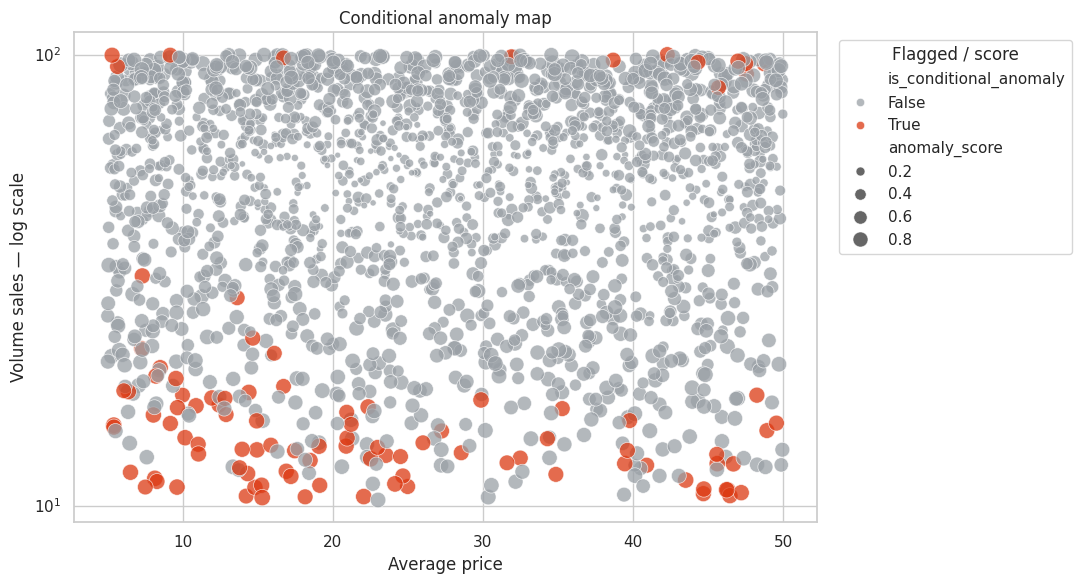

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=plot_df,
    x="average_price",
    y="volume_sales",
    hue="is_conditional_anomaly",
    palette={False: "#9AA0A6", True: "#DC3912"},
    alpha=0.75,
    size="anomaly_score",
    sizes=(18, 140),
    ax=ax,
)
ax.set_yscale("log")
ax.set(title="Conditional anomaly map", xlabel="Average price", ylabel="Volume sales — log scale")
ax.legend(title="Flagged / score", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()